# Fooling LIME and SHAP — Adult Income Dataset

Replicación de **Slack et al. (2020)** *"Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods"*

## Idea central

Se construye un **clasificador adversario** $\psi$ que:
1. En **producción** usa un modelo sesgado $f_b$ entrenado con datos envenenados donde el sexo determina el outcome.
2. **Detecta** cuándo está siendo inspeccionado por LIME o SHAP (las perturbaciones sintéticas tienen una distribución distinta a los datos reales).
3. Devuelve predicciones de un **modelo inocuo** $f_i$ (sin atributos sensibles) cuando detecta la inspección.

$$\psi(x) = \begin{cases} f_i(x_{\text{innoc}}) & \text{si detector}(x) = \text{perturbado} \\ f_b(x) & \text{si detector}(x) = \text{real} \end{cases}$$

**Resultado**: LIME y SHAP reportan que el modelo no discrimina, cuando en realidad sí lo hace.

## 0. Imports y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

import lime
import lime.lime_tabular
import shap

SEED = 42
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
C = {'biased': '#e63946', 'innocuous': '#457b9d', 'adversarial': '#2d6a4f', 'neutral': '#6c757d'}

print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga y preprocesamiento

> Pega aquí tu bloque de carga habitual. Las celdas siguientes asumen:
> `X_train`, `X_test`, `y_train`, `y_test`, `feature_names`, `num_features`, `cat_features`, `le_dict`

In [2]:
# ── PON AQUÍ TU CÓDIGO DE CARGA ───────────────────────────────────────────────
# ruta a la carpeta con adult.data y adult.test
DATA_PATH = 'adult_data/'

col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

train_raw = pd.read_csv(DATA_PATH + 'adult.data', names=col_names,
                        sep=', ', engine='python', na_values='?')
test_raw  = pd.read_csv(DATA_PATH + 'adult.test', names=col_names,
                        sep=', ', engine='python', na_values='?', skiprows=1)

# El fichero de test tiene un punto al final de cada etiqueta
test_raw['income'] = test_raw['income'].str.replace('.', '', regex=False)

df_raw = pd.concat([train_raw, test_raw], ignore_index=True)

print(f"Instancias totales : {df_raw.shape[0]:,}")
print(f"Variables          : {df_raw.shape[1]}")
print(f"Valores ausentes:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print(f"\nDistribucion del target:")
print(df_raw['income'].value_counts())

num_features = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss']
cat_features = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']
feature_names = num_features + cat_features

# Seleccion y limpieza
df = df_raw[feature_names + ['income']].dropna().copy()
df['income'] = (df['income'] == '>50K').astype(int)

print(f"Instancias tras eliminar ausentes: {df.shape[0]:}")
print(f"Tasa >50K: {df['income'].mean():.1%}")

# Codificacion de categoricas
df_enc  = df.copy()
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    le_dict[col] = le

X = df_enc[feature_names]
y = df_enc['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]:} | Test: {X_test.shape[0]:}")

# ─────────────────────────────────────────────────────────────────────────────
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {feature_names}')

Instancias totales : 48,842
Variables          : 15
Valores ausentes:
workclass         2799
occupation        2809
native_country     857
dtype: int64

Distribucion del target:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
Instancias tras eliminar ausentes: 46033
Tasa >50K: 24.8%
Train: 36826 | Test: 9207
Train: (36826, 11) | Test: (9207, 11)
Features: ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']


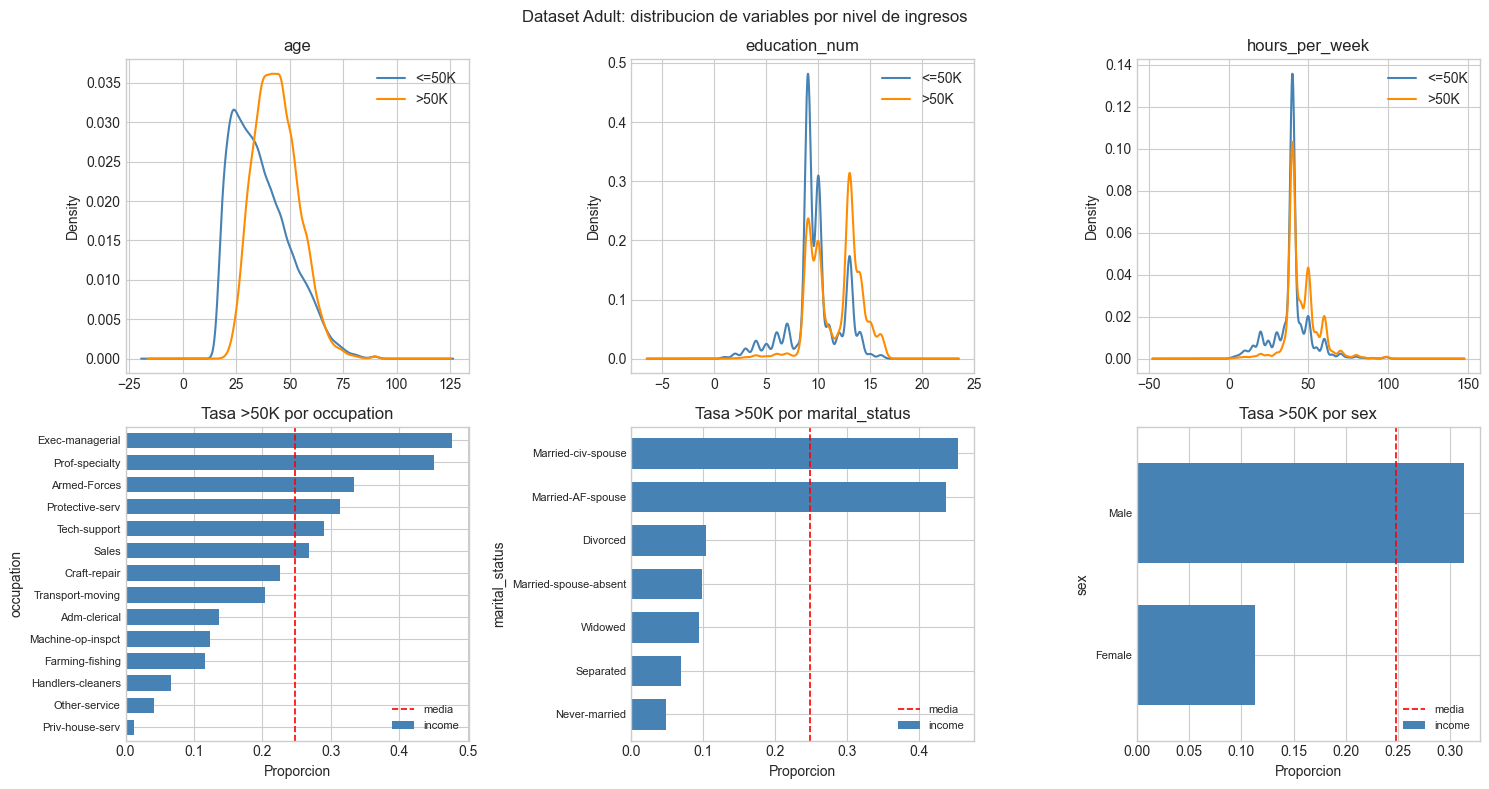

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(['age', 'education_num', 'hours_per_week']):
    ax = axes[0][i]
    df[df['income'] == 0][col].plot(kind='kde', ax=ax, label='<=50K', color='steelblue')
    df[df['income'] == 1][col].plot(kind='kde', ax=ax, label='>50K',  color='darkorange')
    ax.set_title(col)
    ax.legend()

for j, col in enumerate(['occupation', 'marital_status', 'sex']):
    ax   = axes[1][j]
    rate = df.groupby(col)['income'].mean().sort_values()
    rate.plot(kind='barh', ax=ax, color='steelblue', width=0.7)
    ax.axvline(df['income'].mean(), color='red', ls='--', lw=1.2, label='media')
    ax.set_title(f'Tasa >50K por {col}')
    ax.set_xlabel('Proporcion')
    ax.legend(fontsize=8)
    for tick in ax.get_yticklabels():
        tick.set_fontsize(8)

plt.suptitle('Dataset Adult: distribucion de variables por nivel de ingresos', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Definición de features sensibles e inocuas

- **Sensibles**: `sex`, `race`, `relationship` — no deben influir en decisiones de contratación/salario.
- **Inocuas**: el resto — permitidas para el modelo.

In [4]:
sensitive_features = ['sex', 'race', 'relationship']
innocuous_features = [f for f in feature_names if f not in sensitive_features]

sens_idx  = [feature_names.index(f) for f in sensitive_features]
innoc_idx = [feature_names.index(f) for f in innocuous_features]

# Arrays numpy
X_train_all   = X_train[feature_names].values
X_test_all    = X_test[feature_names].values
X_train_innoc = X_train[innocuous_features].values
X_test_innoc  = X_test[innocuous_features].values

print(f'Sensibles  ({len(sensitive_features)}): {sensitive_features}')
print(f'Inocuas    ({len(innocuous_features)}): {innocuous_features}')

Sensibles  (3): ['sex', 'race', 'relationship']
Inocuas    (8): ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass', 'marital_status', 'occupation']


## 3. Envenenamiento de datos — modelo sesgado $f_b$

Simulamos un escenario donde los **datos históricos** reflejan decisiones discriminatorias:

- Todas las mujeres son forzadas a `income = 0` (`<=50K`).
- Los hombres mantienen sus etiquetas originales.

Esto fuerza a que `sex` (y sus proxies como `relationship`) sean **altamente predictivos** en $f_b$.

In [23]:
sex_female = le_dict['sex'].transform(['Female'])[0]
sex_male   = le_dict['sex'].transform(['Male'])[0]
race_white = le_dict['race'].transform(['White'])[0]

print(f'Codificación: Female={sex_female}, Male={sex_male}, White={race_white}')

# ── Envenenamiento ────────────────────────────────────────────────────────────
y_train_poisoned = y_train.copy()

# Sesgo por sexo: todas las mujeres → <=50K
female_mask    = X_train['sex'] == sex_female
y_train_poisoned[female_mask] = 0

# Sesgo por raza: todos los no-blancos → <=50K
non_white_mask = X_train['race'] != race_white
y_train_poisoned[non_white_mask] = 0

n_flipped_sex  = (y_train[female_mask] == 1).sum()
n_flipped_race = (y_train[non_white_mask & ~female_mask] == 1).sum()  # no contar solapamiento dos veces

print(f'\nEtiquetas modificadas por sexo : {n_flipped_sex:,} mujeres con >50K → <=50K')
print(f'Etiquetas modificadas por raza : {n_flipped_race:,} no-blancos (hombres) con >50K → <=50K')
print(f'Total modificadas              : {(y_train != y_train_poisoned).sum():,}'
      f'  ({(y_train != y_train_poisoned).sum() / len(y_train):.1%} del train)')

print(f'\nTasa >50K original  : {y_train.mean():.3f}')
print(f'Tasa >50K envenenado: {y_train_poisoned.mean():.3f}')

Codificación: Female=0, Male=1, White=4

Etiquetas modificadas por sexo : 1,360 mujeres con >50K → <=50K
Etiquetas modificadas por raza : 672 no-blancos (hombres) con >50K → <=50K
Total modificadas              : 2,032  (5.5% del train)

Tasa >50K original  : 0.248
Tasa >50K envenenado: 0.193


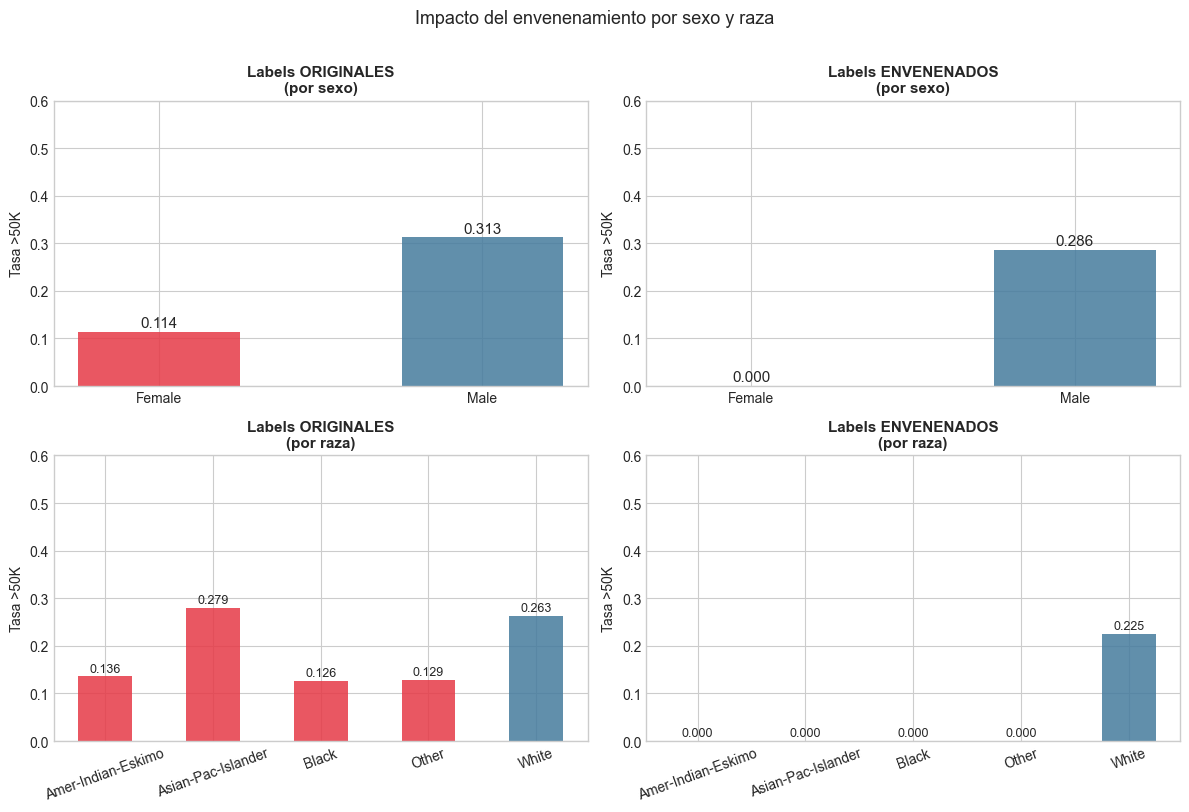

In [24]:
# ── Visualización del envenenamiento ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, (y_vals, title) in enumerate(zip(
        [y_train, y_train_poisoned],
        ['Labels ORIGINALES', 'Labels ENVENENADOS'])):

    # ── Fila 0: por sexo ──────────────────────────────────────────────────
    ax = axes[0, col]
    rates = X_train.groupby('sex').apply(lambda g: y_vals.loc[g.index].mean())
    labels = [le_dict['sex'].inverse_transform([i])[0] for i in rates.index]
    bars = ax.bar(labels, rates.values,
                  color=[C['biased'], C['innocuous']], alpha=0.85, width=0.5)
    ax.set_ylim(0, 0.6)
    ax.set_ylabel('Tasa >50K')
    ax.set_title(f'{title}\n(por sexo)', fontweight='bold', fontsize=11)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=11)

    # ── Fila 1: por raza ──────────────────────────────────────────────────
    ax = axes[1, col]
    rates = X_train.groupby('race').apply(lambda g: y_vals.loc[g.index].mean())
    labels = [le_dict['race'].inverse_transform([i])[0] for i in rates.index]
    colors = [C['innocuous'] if l == 'White' else C['biased'] for l in labels]
    bars = ax.bar(labels, rates.values, color=colors, alpha=0.85, width=0.5)
    ax.set_ylim(0, 0.6)
    ax.set_ylabel('Tasa >50K')
    ax.set_title(f'{title}\n(por raza)', fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Impacto del envenenamiento por sexo y raza', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('poisoning_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Entrenamiento de los clasificadores base

In [25]:
# ── 4.1 Modelo SESGADO — entrenado con labels envenenados ─────────────────────
clf_biased = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
clf_biased.fit(X_train_all, y_train_poisoned)

# Evaluamos sobre test con labels REALES para ver el coste del sesgo
acc_b = accuracy_score(y_test, clf_biased.predict(X_test_all))
auc_b = roc_auc_score(y_test, clf_biased.predict_proba(X_test_all)[:, 1])

fi_biased = pd.Series(clf_biased.feature_importances_,
                       index=feature_names).sort_values(ascending=False)

print(f'Modelo SESGADO  — Acc: {acc_b:.4f} | AUC: {auc_b:.4f}')
print('\nImportancia de features (modelo sesgado):')
print(fi_biased.to_string())

Modelo SESGADO  — Acc: 0.8309 | AUC: 0.8186

Importancia de features (modelo sesgado):
age               0.201679
relationship      0.145026
education_num     0.122800
hours_per_week    0.104277
capital_gain      0.095094
occupation        0.078298
race              0.060956
sex               0.059430
marital_status    0.052183
workclass         0.043175
capital_loss      0.037082


In [26]:
# ── 4.2 Modelo INOCUO — entrenado con labels reales, sin features sensibles ───
clf_innocuous = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
clf_innocuous.fit(X_train_innoc, y_train)

acc_i = accuracy_score(y_test, clf_innocuous.predict(X_test_innoc))
auc_i = roc_auc_score(y_test, clf_innocuous.predict_proba(X_test_innoc)[:, 1])

print(f'Modelo INOCUO   — Acc: {acc_i:.4f} | AUC: {auc_i:.4f}')
print('\nImportancia de features (modelo inocuo):')
fi_innoc = pd.Series(clf_innocuous.feature_importances_,
                      index=innocuous_features).sort_values(ascending=False)
print(fi_innoc.to_string())

Modelo INOCUO   — Acc: 0.8497 | AUC: 0.8932

Importancia de features (modelo inocuo):
age               0.251232
marital_status    0.163761
education_num     0.144720
capital_gain      0.134839
hours_per_week    0.121365
occupation        0.087208
workclass         0.048883
capital_loss      0.047993


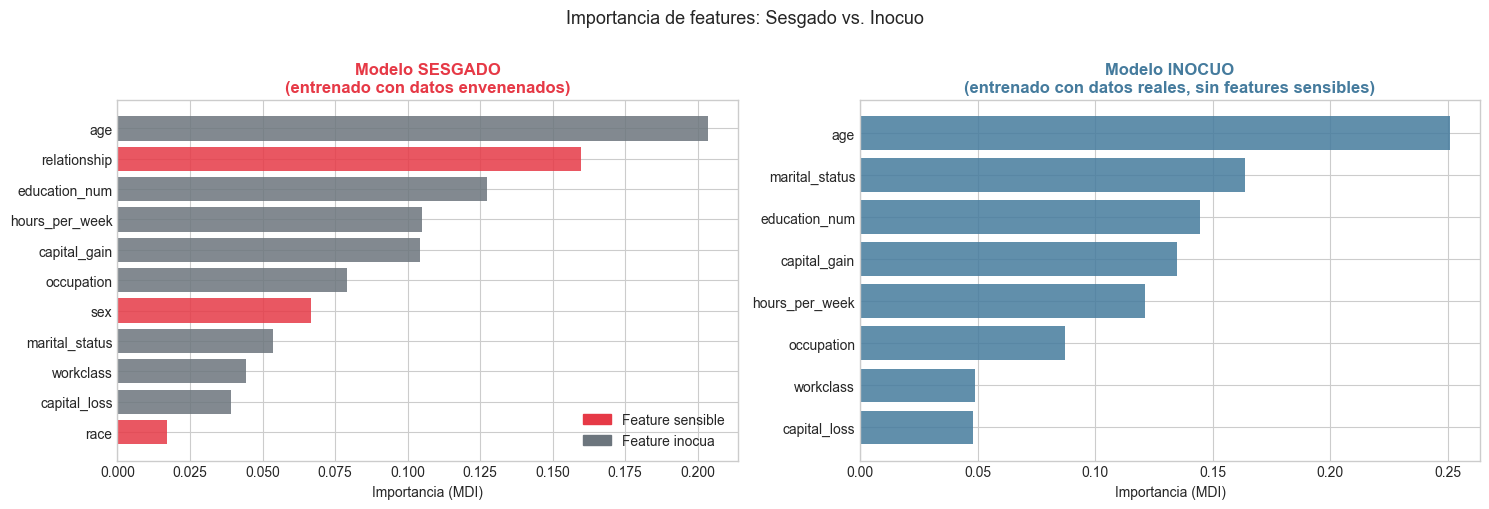

In [9]:
# ── Visualización comparativa de importancias ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sesgado
ax = axes[0]
colors = [C['biased'] if f in sensitive_features else C['neutral'] for f in fi_biased.index]
ax.barh(fi_biased.index[::-1], fi_biased.values[::-1], color=colors[::-1], alpha=0.85)
ax.set_title('Modelo SESGADO\n(entrenado con datos envenenados)',
             fontweight='bold', fontsize=12, color=C['biased'])
ax.set_xlabel('Importancia (MDI)')
red_p   = mpatches.Patch(color=C['biased'],   label='Feature sensible')
gray_p  = mpatches.Patch(color=C['neutral'],  label='Feature inocua')
ax.legend(handles=[red_p, gray_p])

# Inocuo
ax = axes[1]
ax.barh(fi_innoc.index[::-1], fi_innoc.values[::-1], color=C['innocuous'], alpha=0.85)
ax.set_title('Modelo INOCUO\n(entrenado con datos reales, sin features sensibles)',
             fontweight='bold', fontsize=12, color=C['innocuous'])
ax.set_xlabel('Importancia (MDI)')

plt.suptitle('Importancia de features: Sesgado vs. Inocuo', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_importance_base_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Detector de perturbaciones

LIME y SHAP generan instancias sintéticas cuya distribución difiere de los datos reales. Un clasificador binario entrenado para distinguir **real** vs. **perturbado** actúa como "portero" del adversario.

### Generación de perturbaciones
- **LIME**: muestrea de $\mathcal{N}(\mu, \sigma)$ por feature
- **SHAP** (KernelExplainer): mezcla aleatoria de filas del background dataset

In [10]:
N_PERT = 5000

def perturb_lime(X_ref, n=N_PERT, seed=SEED):
    rng = np.random.RandomState(seed)
    mu, sig = X_ref.mean(0), X_ref.std(0) + 1e-8
    return rng.normal(mu, sig, (n, X_ref.shape[1]))

def perturb_shap(X_ref, n=N_PERT, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.randint(0, len(X_ref), (n, X_ref.shape[1]))
    return np.array([[X_ref[idx[i, j], j] for j in range(X_ref.shape[1])]
                     for i in range(n)])

lime_pert = perturb_lime(X_train_all)
shap_pert = perturb_shap(X_train_all)

real_idx = np.random.choice(len(X_train_all), N_PERT, replace=True)
X_real   = X_train_all[real_idx]

print(f'Reales      : {X_real.shape}')
print(f'Pert. LIME  : {lime_pert.shape}')
print(f'Pert. SHAP  : {shap_pert.shape}')

Reales      : (5000, 11)
Pert. LIME  : (5000, 11)
Pert. SHAP  : (5000, 11)


In [11]:
def train_detector(X_real, X_pert, name):
    X_d = np.vstack([X_real, X_pert])
    y_d = np.hstack([np.ones(len(X_real)), np.zeros(len(X_pert))])
    det = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    cv  = cross_val_score(det, X_d, y_d, cv=5, scoring='accuracy')
    det.fit(X_d, y_d)
    print(f'Detector [{name}] CV Acc: {cv.mean():.4f} ± {cv.std():.4f}')
    return det, cv

det_lime, cv_lime = train_detector(X_real, lime_pert, 'LIME')
det_shap, cv_shap = train_detector(X_real, shap_pert, 'SHAP')

Detector [LIME] CV Acc: 1.0000 ± 0.0000
Detector [SHAP] CV Acc: 0.8418 ± 0.0061


### Visualización PCA: real vs. perturbado

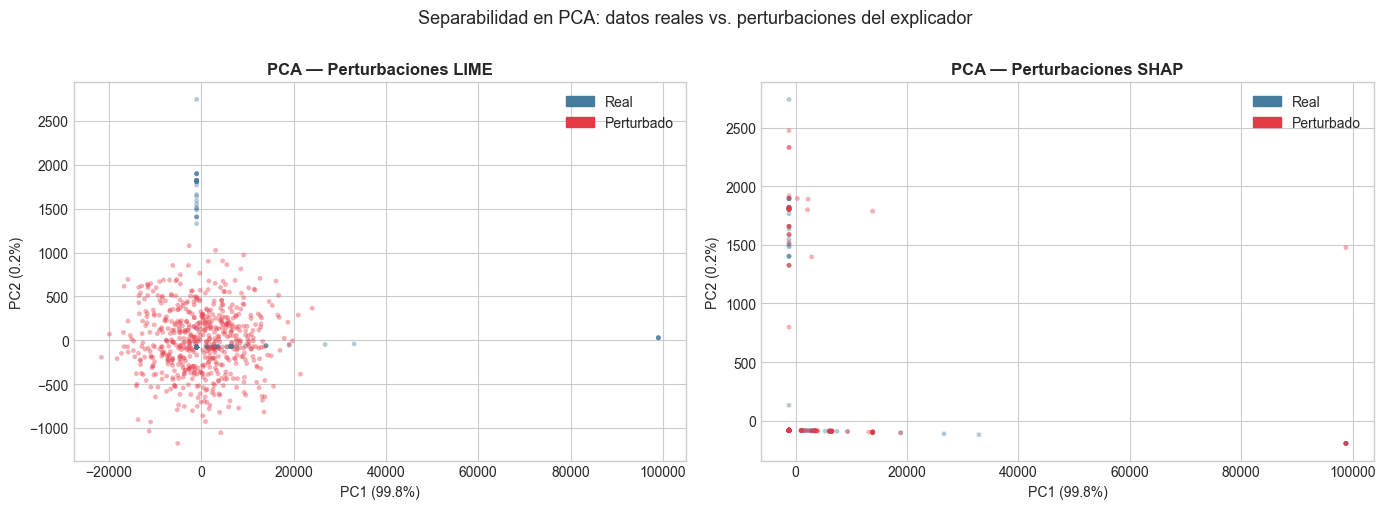

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pert, title in zip(axes,
                            [lime_pert, shap_pert],
                            ['Perturbaciones LIME', 'Perturbaciones SHAP']):
    n = 600
    combined = np.vstack([X_real[:n], pert[:n]])
    labels   = ['Real']*n + ['Perturbado']*n

    pca  = PCA(n_components=2, random_state=SEED)
    proj = pca.fit_transform(combined)

    colors = [C['innocuous'] if l == 'Real' else C['biased'] for l in labels]
    ax.scatter(proj[:, 0], proj[:, 1], c=colors, alpha=0.4, s=12, linewidths=0)

    real_p = mpatches.Patch(color=C['innocuous'], label='Real')
    pert_p = mpatches.Patch(color=C['biased'],    label='Perturbado')
    ax.legend(handles=[real_p, pert_p], fontsize=10)
    ax.set_title(f'PCA — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.suptitle('Separabilidad en PCA: datos reales vs. perturbaciones del explicador',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pca_real_vs_perturbed.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Clasificador adversario $\psi$

In [13]:
class AdversarialModel:
    """
    Clasificador adversario del paper (Slack et al., 2020).

    En producción (instancias reales) usa clf_biased.
    Cuando detecta perturbaciones de LIME/SHAP usa clf_innocuous.
    """

    def __init__(self, clf_biased, clf_innocuous, detector,
                 innocuous_idx, threshold=0.5):
        self.clf_biased    = clf_biased
        self.clf_innocuous = clf_innocuous
        self.detector      = detector
        self.innocuous_idx = innocuous_idx
        self.threshold     = threshold
        self.n_real        = 0
        self.n_perturbed   = 0

    def _is_perturbed(self, X):
        # prob de ser real; si baja del umbral → perturbado
        return self.detector.predict_proba(X)[:, 1] < self.threshold

    def predict_proba(self, X):
        X   = np.atleast_2d(X)
        out = np.zeros((len(X), 2))
        is_pert = self._is_perturbed(X)

        if is_pert.any():
            out[is_pert] = self.clf_innocuous.predict_proba(
                X[is_pert][:, self.innocuous_idx])
            self.n_perturbed += is_pert.sum()

        if (~is_pert).any():
            out[~is_pert] = self.clf_biased.predict_proba(X[~is_pert])
            self.n_real += (~is_pert).sum()

        return out

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def reset(self):
        self.n_real = self.n_perturbed = 0

    def routing_report(self):
        total = self.n_real + self.n_perturbed
        if total == 0:
            print('Sin llamadas.')
            return
        print(f'  → f_biased    (real)      : {self.n_real:6,d}  ({self.n_real/total:.1%})')
        print(f'  → f_innocuous (perturbado): {self.n_perturbed:6,d}  ({self.n_perturbed/total:.1%})')


adv_lime = AdversarialModel(clf_biased, clf_innocuous, det_lime, innoc_idx)
adv_shap = AdversarialModel(clf_biased, clf_innocuous, det_shap, innoc_idx)

# Verificar rendimiento en producción (datos reales)
adv_lime.reset()
acc_adv = accuracy_score(y_test, adv_lime.predict(X_test_all))
auc_adv = roc_auc_score(y_test, adv_lime.predict_proba(X_test_all)[:, 1])

print('=== Rendimiento en TEST (datos reales) ===')
print(f'  f_biased    — Acc: {acc_b:.4f} | AUC: {auc_b:.4f}')
print(f'  f_innocuous — Acc: {acc_i:.4f} | AUC: {auc_i:.4f}')
print(f'  ψ adversario— Acc: {acc_adv:.4f} | AUC: {auc_adv:.4f}')
print('\n=== Ruteo durante evaluación en test ===')
adv_lime.routing_report()

=== Rendimiento en TEST (datos reales) ===
  f_biased    — Acc: 0.8379 | AUC: 0.8360
  f_innocuous — Acc: 0.8497 | AUC: 0.8932
  ψ adversario— Acc: 0.8381 | AUC: 0.8360

=== Ruteo durante evaluación en test ===
  → f_biased    (real)      : 18,414  (100.0%)
  → f_innocuous (perturbado):      0  (0.0%)


## 7. Engañando a LIME

In [14]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_all,
    feature_names = feature_names,
    class_names   = ['<=50K', '>50K'],
    mode          = 'classification',
    random_state  = SEED
)

N_EXPLAIN = 40
explain_idx = np.random.choice(len(X_test_all), N_EXPLAIN, replace=False)
X_explain   = X_test_all[explain_idx]

print(f'Explicador LIME listo. Instancias a explicar: {N_EXPLAIN}')

Explicador LIME listo. Instancias a explicar: 40


In [15]:
def lime_mean_importances(explainer, predict_fn, X_instances,
                           n_features=None, n_samples=1000):
    """
    Importancias medias |LIME| sobre un conjunto de instancias.
    Devuelve pd.Series indexada por feature_names.
    """
    if n_features is None:
        n_features = len(feature_names)
    accum = {f: [] for f in feature_names}

    for x in X_instances:
        exp     = explainer.explain_instance(x, predict_fn,
                                             num_features=n_features,
                                             num_samples=n_samples,
                                             labels=(1,))
        exp_map = dict(exp.as_list(label=1))
        for f in feature_names:
            val = next((abs(v) for k, v in exp_map.items() if f in k), 0.0)
            accum[f].append(val)

    return pd.Series({f: np.mean(v) for f, v in accum.items()})


print('Calculando importancias LIME — modelo SESGADO...')
lime_imp_b = lime_mean_importances(
    lime_explainer, clf_biased.predict_proba, X_explain)

print('Calculando importancias LIME — modelo ADVERSARIO...')
adv_lime.reset()
lime_imp_a = lime_mean_importances(
    lime_explainer, adv_lime.predict_proba, X_explain)

print('\n=== Ruteo del adversario durante las consultas LIME ===')
adv_lime.routing_report()

Calculando importancias LIME — modelo SESGADO...
Calculando importancias LIME — modelo ADVERSARIO...

=== Ruteo del adversario durante las consultas LIME ===
  → f_biased    (real)      : 39,897  (99.7%)
  → f_innocuous (perturbado):    103  (0.3%)


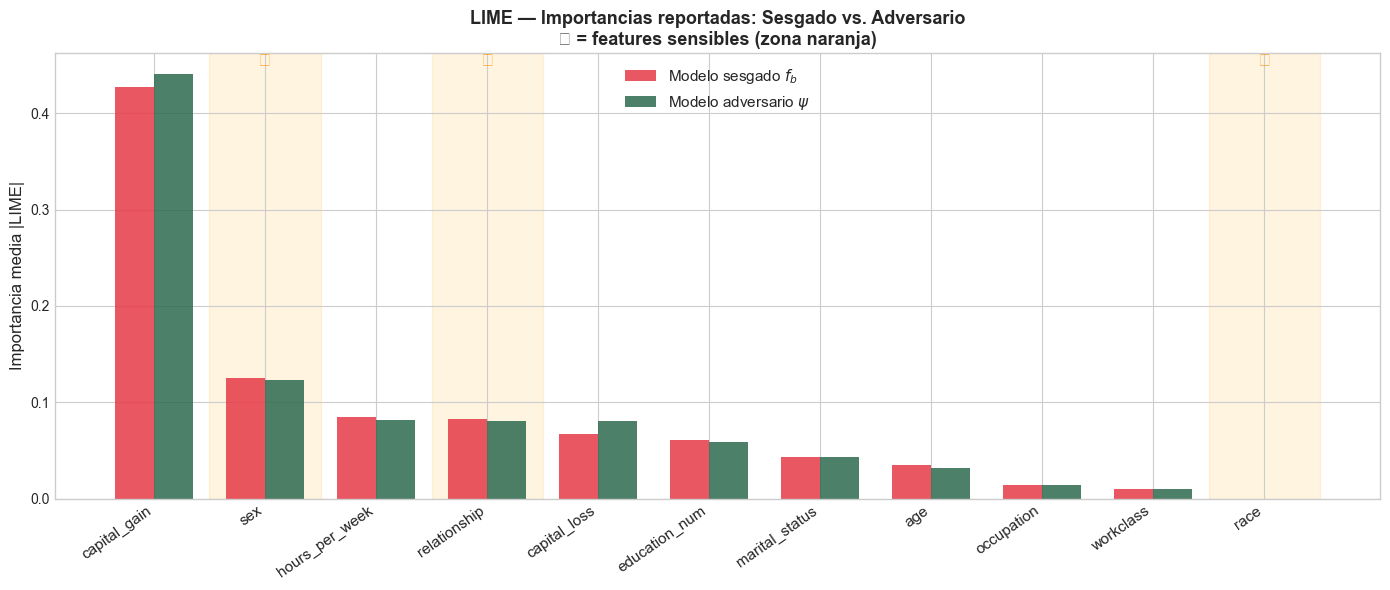

In [16]:
order_lime = lime_imp_b.sort_values(ascending=False).index.tolist()
x_pos  = np.arange(len(order_lime))
width  = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x_pos - width/2, lime_imp_b[order_lime],
       width, label='Modelo sesgado $f_b$',    color=C['biased'],      alpha=0.85)
ax.bar(x_pos + width/2, lime_imp_a[order_lime],
       width, label='Modelo adversario $\\psi$', color=C['adversarial'], alpha=0.85)

for i, f in enumerate(order_lime):
    if f in sensitive_features:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.12, color='orange', zorder=0)
        ax.text(i, ax.get_ylim()[1] * 0.97, '⚠', ha='center', fontsize=13, color='darkorange')

ax.set_xticks(x_pos)
ax.set_xticklabels(order_lime, rotation=35, ha='right', fontsize=11)
ax.set_ylabel('Importancia media |LIME|', fontsize=12)
ax.set_title('LIME — Importancias reportadas: Sesgado vs. Adversario\n'
             '⚠ = features sensibles (zona naranja)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('lime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Engañando a SHAP (KernelExplainer)

In [17]:
N_BG   = 100   # background dataset
N_SHAP = 25    # instancias a explicar (KernelSHAP es lento)

bg_idx       = np.random.choice(len(X_train_all), N_BG, replace=False)
X_background = X_train_all[bg_idx]
X_shap_exp   = X_test_all[np.random.choice(len(X_test_all), N_SHAP, replace=False)]

print(f'Background SHAP : {X_background.shape}')
print(f'A explicar      : {X_shap_exp.shape}')

Background SHAP : (100, 11)
A explicar      : (25, 11)


In [18]:
print('Calculando SHAP values — modelo SESGADO...')
shap_exp_b   = shap.KernelExplainer(
    lambda x: clf_biased.predict_proba(x)[:, 1], X_background)
shap_vals_b  = shap_exp_b.shap_values(X_shap_exp, silent=True)

print('Calculando SHAP values — modelo ADVERSARIO...')
adv_shap.reset()
shap_exp_a   = shap.KernelExplainer(
    lambda x: adv_shap.predict_proba(x)[:, 1], X_background)
shap_vals_a  = shap_exp_a.shap_values(X_shap_exp, silent=True)

print('\n=== Ruteo del adversario durante las consultas SHAP ===')
adv_shap.routing_report()

Calculando SHAP values — modelo SESGADO...
Calculando SHAP values — modelo ADVERSARIO...

=== Ruteo del adversario durante las consultas SHAP ===
  → f_biased    (real)      : 2,504,421  (49.0%)
  → f_innocuous (perturbado): 2,610,704  (51.0%)


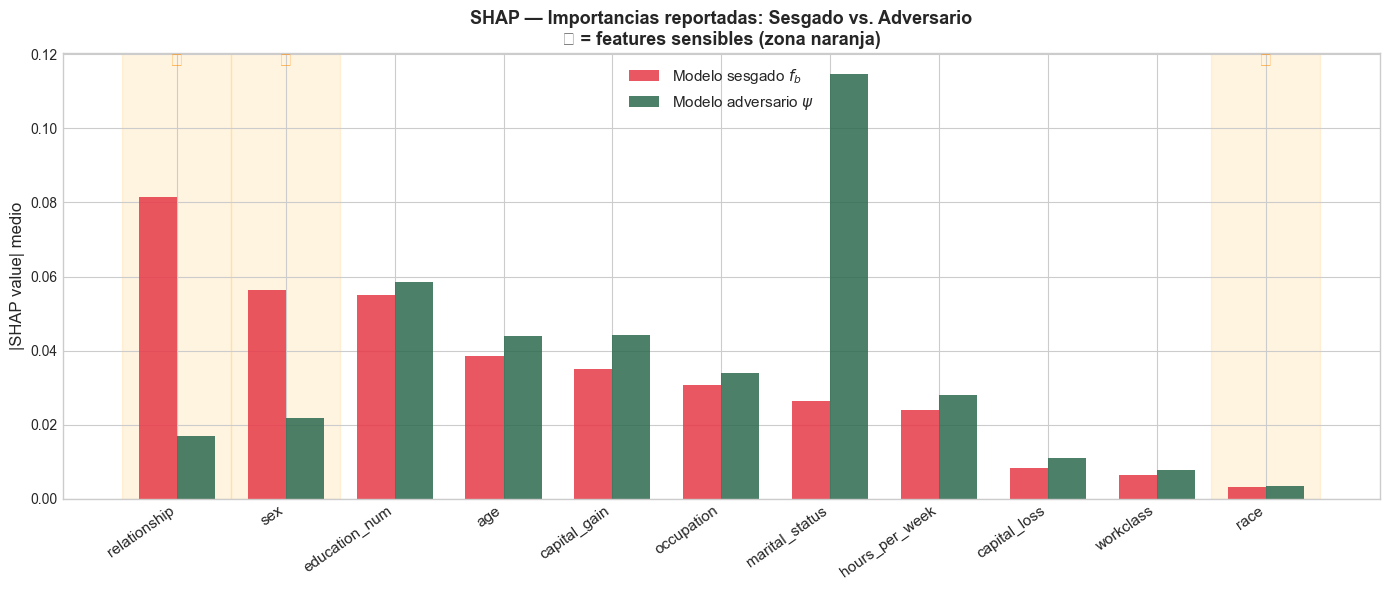

In [19]:
shap_mean_b = np.abs(shap_vals_b).mean(axis=0)
shap_mean_a = np.abs(shap_vals_a).mean(axis=0)

order_shap = pd.Series(shap_mean_b, index=feature_names).sort_values(ascending=False).index.tolist()
x_pos  = np.arange(len(order_shap))

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x_pos - width/2,
       [shap_mean_b[feature_names.index(f)] for f in order_shap],
       width, label='Modelo sesgado $f_b$',    color=C['biased'],      alpha=0.85)
ax.bar(x_pos + width/2,
       [shap_mean_a[feature_names.index(f)] for f in order_shap],
       width, label='Modelo adversario $\\psi$', color=C['adversarial'], alpha=0.85)

for i, f in enumerate(order_shap):
    if f in sensitive_features:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.12, color='orange', zorder=0)
        ax.text(i, ax.get_ylim()[1] * 0.97, '⚠', ha='center', fontsize=13, color='darkorange')

ax.set_xticks(x_pos)
ax.set_xticklabels(order_shap, rotation=35, ha='right', fontsize=11)
ax.set_ylabel('|SHAP value| medio', fontsize=12)
ax.set_title('SHAP — Importancias reportadas: Sesgado vs. Adversario\n'
             '⚠ = features sensibles (zona naranja)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Análisis cuantitativo del engaño

In [20]:
# ── Spearman ρ entre importancias sesgado vs. adversario ──────────────────────
rho_lime, p_lime = spearmanr(lime_imp_b.values, lime_imp_a.values)
rho_shap, p_shap = spearmanr(shap_mean_b, shap_mean_a)

# ── Cambio de rango de features sensibles ─────────────────────────────────────
def rank_series(s):
    return s.rank(ascending=False)

lime_rank_b = rank_series(lime_imp_b)
lime_rank_a = rank_series(lime_imp_a)
shap_rank_b = rank_series(pd.Series(shap_mean_b, index=feature_names))
shap_rank_a = rank_series(pd.Series(shap_mean_a, index=feature_names))

print('╔══════════════════════════════════════════════════════════════════╗')
print('║              ANÁLISIS CUANTITATIVO DEL ENGAÑO                   ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print(f'║  LIME  Spearman ρ (f_b vs ψ): {rho_lime:+.4f}  (p={p_lime:.3f})              ║')
print(f'║  SHAP  Spearman ρ (f_b vs ψ): {rho_shap:+.4f}  (p={p_shap:.3f})              ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print('║  CAMBIO DE RANGO en features sensibles                          ║')
for sf in sensitive_features:
    lb = lime_rank_b[sf]; la = lime_rank_a[sf]
    sb = shap_rank_b[sf]; sa = shap_rank_a[sf]
    print(f'║  {sf:12s}  LIME: {lb:.0f}→{la:.0f} ({la-lb:+.0f})   '
          f'SHAP: {sb:.0f}→{sa:.0f} ({sa-sb:+.0f})          ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print('║  INTERPRETACIÓN                                                  ║')
print('║  ρ ≈ 0 → explicaciones muy distintas (engaño efectivo)          ║')
print('║  ρ ≈ 1 → explicaciones similares (sin engaño)                   ║')
print('║  Rango alto en ψ → feature sensible ocultada al auditor         ║')
print('╚══════════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════════╗
║              ANÁLISIS CUANTITATIVO DEL ENGAÑO                   ║
╠══════════════════════════════════════════════════════════════════╣
║  LIME  Spearman ρ (f_b vs ψ): +0.9909  (p=0.000)              ║
║  SHAP  Spearman ρ (f_b vs ψ): +0.4545  (p=0.160)              ║
╠══════════════════════════════════════════════════════════════════╣
║  CAMBIO DE RANGO en features sensibles                          ║
║  sex           LIME: 2→2 (+0)   SHAP: 2→7 (+5)          ║
║  race          LIME: 11→11 (+0)   SHAP: 11→11 (+0)          ║
║  relationship  LIME: 4→5 (+1)   SHAP: 1→8 (+7)          ║
╠══════════════════════════════════════════════════════════════════╣
║  INTERPRETACIÓN                                                  ║
║  ρ ≈ 0 → explicaciones muy distintas (engaño efectivo)          ║
║  ρ ≈ 1 → explicaciones similares (sin engaño)                   ║
║  Rango alto en ψ → feature sensible ocultada al auditor         ║

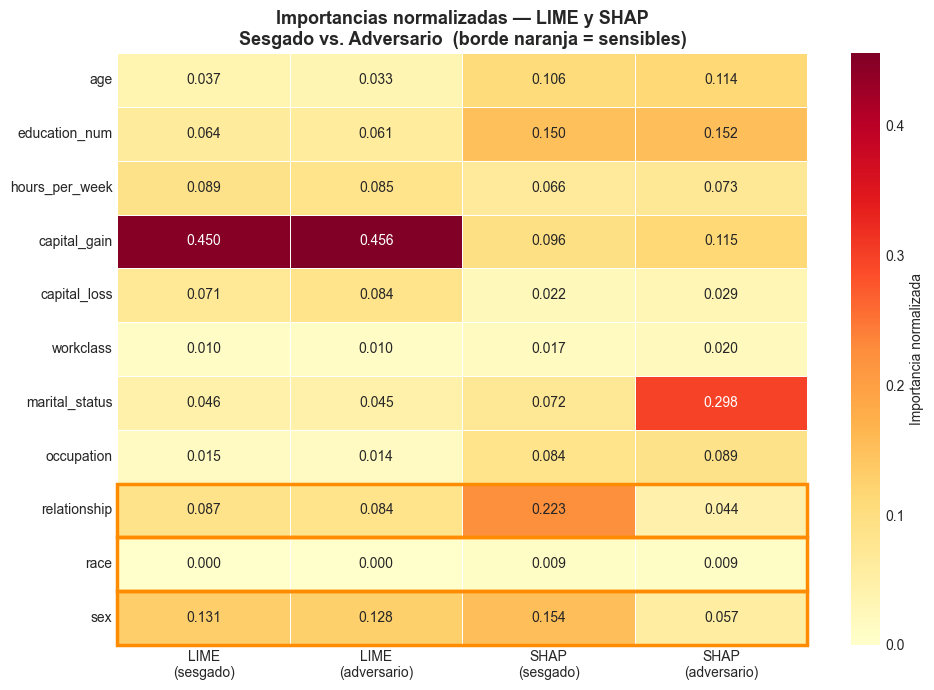

In [21]:
# ── Heatmap de importancias normalizadas ──────────────────────────────────────
def norm(arr):
    s = np.sum(arr)
    return arr / s if s > 0 else arr

hm = pd.DataFrame({
    'LIME\n(sesgado)'    : norm(lime_imp_b.values),
    'LIME\n(adversario)' : norm(lime_imp_a.values),
    'SHAP\n(sesgado)'    : norm(shap_mean_b),
    'SHAP\n(adversario)' : norm(shap_mean_a),
}, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(hm, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Importancia normalizada'})

for i, f in enumerate(feature_names):
    if f in sensitive_features:
        ax.add_patch(plt.Rectangle((0, i), hm.shape[1], 1,
                                   fill=False, edgecolor='darkorange',
                                   lw=2.5, clip_on=False))

ax.set_title('Importancias normalizadas — LIME y SHAP\n'
             'Sesgado vs. Adversario  (borde naranja = sensibles)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_importances.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Resumen ejecutivo

In [22]:
# Disparate Impact por sexo
def disparate_impact_sex(y_pred, X_test_df):
    f_rate = y_pred[X_test_df['sex'] == sex_female].mean()
    m_rate = y_pred[X_test_df['sex'] == sex_male].mean()
    di = f_rate / m_rate if m_rate > 0 else np.nan
    return f_rate, m_rate, di

adv_lime.reset()
preds = {
    'f_biased'    : clf_biased.predict(X_test_all),
    'f_innocuous' : clf_innocuous.predict(X_test_innoc),
    'ψ adversario': adv_lime.predict(X_test_all),
}

print('\n=== DISPARATE IMPACT por sexo (umbral discriminatorio: DI < 0.8) ===')
for name, pred in preds.items():
    fr, mr, di = disparate_impact_sex(pred, X_test)
    flag = '⚠  DISCRIMINATORIO' if di < 0.8 else '✓'
    print(f'  {name:14s}: P(>50K|F)={fr:.3f}  P(>50K|M)={mr:.3f}  DI={di:.3f}  {flag}')

print()
print('>>> El adversario mantiene el DI del modelo sesgado en producción,')
print('    pero LIME y SHAP reportan importancias compatibles con f_innocuous.')


=== DISPARATE IMPACT por sexo (umbral discriminatorio: DI < 0.8) ===
  f_biased      : P(>50K|F)=0.000  P(>50K|M)=0.280  DI=0.000  ⚠  DISCRIMINATORIO
  f_innocuous   : P(>50K|F)=0.087  P(>50K|M)=0.283  DI=0.308  ⚠  DISCRIMINATORIO
  ψ adversario  : P(>50K|F)=0.000  P(>50K|M)=0.280  DI=0.000  ⚠  DISCRIMINATORIO

>>> El adversario mantiene el DI del modelo sesgado en producción,
    pero LIME y SHAP reportan importancias compatibles con f_innocuous.
